In [2]:
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=AADI13\SQLEXPRESS;"
    "DATABASE=Customer Churn;"
    "Trusted_Connection=yes;"
)

df = pd.read_sql("SELECT * FROM Customer_Churn", conn)

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,False,True,False,1,False,None,DSL,False,...,False,False,False,False,Month-to-month,True,Electronic check,29.850000,29.850000,False
1,5575-GNVDE,Male,False,False,False,34,True,False,DSL,True,...,True,False,False,False,One year,False,Mailed check,56.950001,1889.500000,False
2,3668-QPYBK,Male,False,False,False,2,True,False,DSL,True,...,False,False,False,False,Month-to-month,True,Mailed check,53.849998,108.150002,True
3,7795-CFOCW,Male,False,False,False,45,False,None,DSL,True,...,True,True,False,False,One year,False,Bank transfer (automatic),42.299999,1840.750000,False
4,9237-HQITU,Female,False,False,False,2,True,False,Fiber optic,False,...,False,False,False,False,Month-to-month,True,Electronic check,70.699997,151.649994,True


In [3]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [4]:
df.duplicated().sum()

# No duplicates in the dataframe

0

In [4]:
df=df.drop(['customerID'],axis=1)

# customerID has no role to play in analysis

In [5]:
df.shape

(7043, 20)

In [7]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()
print(num_cols)

['tenure', 'MonthlyCharges', 'TotalCharges']


In [8]:
numerical_cols = df.select_dtypes(include=['number'])
numerical_cols.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771363
min,0.000000,18.250000,18.799999
25%,9.000000,35.500000,401.449997
50%,29.000000,70.349998,1397.475037
75%,55.000000,89.849998,3794.737488
max,72.000000,118.750000,8684.799805


In [149]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(cat_cols)

['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [7]:
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
print(bool_cols)

['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']


In [8]:
df[bool_cols] = df[bool_cols].astype(int)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int32  
 2   Partner           7043 non-null   int32  
 3   Dependents        7043 non-null   int32  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int32  
 6   MultipleLines     6361 non-null   object 
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    5517 non-null   object 
 9   OnlineBackup      5517 non-null   object 
 10  DeviceProtection  5517 non-null   object 
 11  TechSupport       5517 non-null   object 
 12  StreamingTV       5517 non-null   object 
 13  StreamingMovies   5517 non-null   object 
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   int32  
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [153]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,1,0,1,0,None,DSL,False,True,False,False,False,False,Month-to-month,1,Electronic check,29.850000,29.850000,0
1,Male,0,0,0,34,1,False,DSL,True,False,True,False,False,False,One year,0,Mailed check,56.950001,1889.500000,0
2,Male,0,0,0,2,1,False,DSL,True,True,False,False,False,False,Month-to-month,1,Mailed check,53.849998,108.150002,1
3,Male,0,0,0,45,0,None,DSL,True,False,True,True,False,False,One year,0,Bank transfer (automatic),42.299999,1840.750000,0
4,Female,0,0,0,2,1,False,Fiber optic,False,False,False,False,False,False,Month-to-month,1,Electronic check,70.699997,151.649994,1


## Imputing Missing Values

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int32  
 2   Partner           7043 non-null   int32  
 3   Dependents        7043 non-null   int32  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int32  
 6   MultipleLines     6361 non-null   object 
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    5517 non-null   object 
 9   OnlineBackup      5517 non-null   object 
 10  DeviceProtection  5517 non-null   object 
 11  TechSupport       5517 non-null   object 
 12  StreamingTV       5517 non-null   object 
 13  StreamingMovies   5517 non-null   object 
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   int32  
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [155]:
# All Object columns have null

obj_cols = df.select_dtypes(include=['object']).columns

for col in obj_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False))


Column: gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Column: MultipleLines
MultipleLines
False    3390
True     2971
None      682
Name: count, dtype: int64

Column: InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Column: OnlineSecurity
OnlineSecurity
False    3498
True     2019
None     1526
Name: count, dtype: int64

Column: OnlineBackup
OnlineBackup
False    3088
True     2429
None     1526
Name: count, dtype: int64

Column: DeviceProtection
DeviceProtection
False    3095
True     2422
None     1526
Name: count, dtype: int64

Column: TechSupport
TechSupport
False    3473
True     2044
None     1526
Name: count, dtype: int64

Column: StreamingTV
StreamingTV
False    2810
True     2707
None     1526
Name: count, dtype: int64

Column: StreamingMovies
StreamingMovies
False    2785
True     2732
None     1526
Name: count, dtype: int64

Column: Contract
Contract
Month-to-month    3875
Two yea

In [156]:
df.loc[df['StreamingMovies'].isnull(),['InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']]

# None are the customers with no internet service 

,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
11,No,None,None,None,None,None,None
16,No,None,None,None,None,None,None
21,No,None,None,None,None,None,None
22,No,None,None,None,None,None,None
33,No,None,None,None,None,None,None
...,...,...,...,...,...,...,...
7017,No,None,None,None,None,None,None
7019,No,None,None,None,None,None,None
7020,No,None,None,None,None,None,None
7030,No,None,None,None,None,None,None


In [14]:
cols = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies'] 
df[cols] = df[cols].fillna('No Internet Service')

In [15]:
df.isna().sum()

gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines       682
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
MonthlyCharges        0
TotalCharges         11
Churn                 0
dtype: int64

In [16]:
df['MultipleLines']=df['MultipleLines'].fillna(df['MultipleLines'].mode()[0])

# Either a customer can have multiple lines or not

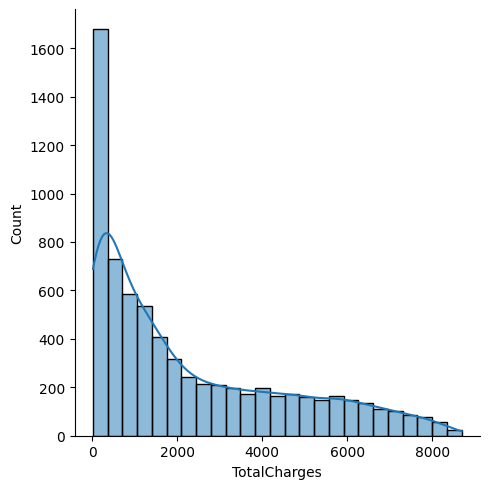

In [160]:
# Checking distribution of TotalCharges

sns.displot(data=df, x='TotalCharges', kind='hist',kde=True)
plt.show()

In [17]:
mask = df['TotalCharges'].isna()
df.loc[mask, 'TotalCharges'] = (
    df.loc[mask, 'MonthlyCharges'] * df.loc[mask, 'tenure']
)

# At Missing values place, TotalCharges=MonthlyCharges*Tenure

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int32  
 2   Partner           7043 non-null   int32  
 3   Dependents        7043 non-null   int32  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int32  
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   int32  
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

## Checking for Outliers

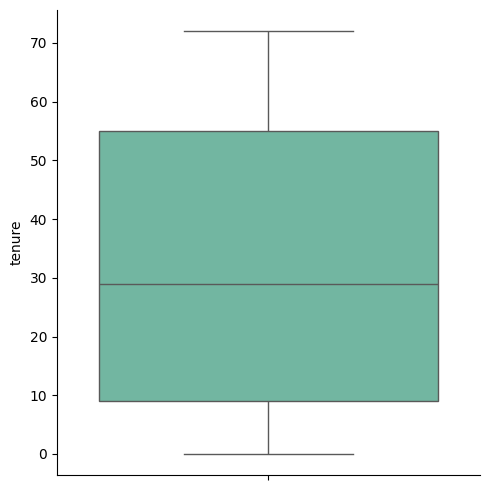

In [162]:
sns.catplot(data=df,y='tenure',kind='box',palette="Set2")
plt.show()

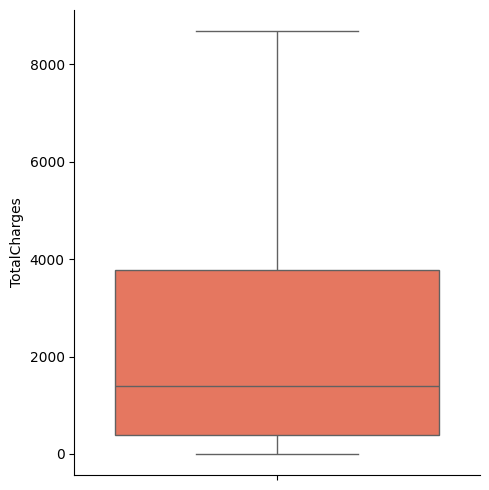

In [163]:
sns.catplot(data=df,y='TotalCharges',kind='box',palette="Reds")
plt.show()

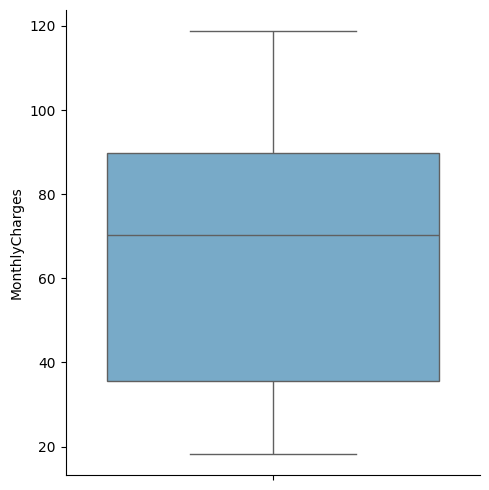

In [164]:
sns.catplot(data=df,y='MonthlyCharges',kind='box',palette="Blues")
plt.show()

In [165]:
# No ouliers present

## Churn Analysis

In [18]:
# Calculating churn rate

churn_rate = (len(df.loc[df['Churn']==1])/df.shape[0])*100
print(churn_rate)

26.536987079369588


In [12]:
# Annual Revenue Lost

Lost_Monthly_revenue = df.loc[df['Churn'] == 1, 'MonthlyCharges'].sum()
Annual_revenue_lost = Lost_Monthly_revenue * 12
print(Annual_revenue_lost)

1669570.200164795


In [20]:
# Male vs female churn rate

df_m = df.loc[df['gender']=='Male','Churn'].reset_index()
male_churn_rate = (len(df_m.loc[df_m['Churn'] == 1])/len(df.loc[df['gender']=='Male']))*100
print(f"Male churn rate is {male_churn_rate}")

df_f = df.loc[df['gender']=='Female','Churn'].reset_index()
female_churn_rate = (len(df_f.loc[df_f['Churn'] == 1])/len(df.loc[df['gender']=='Female']))*100
print(f"Female churn rate is {female_churn_rate}")

Male churn rate is 26.160337552742618
Female churn rate is 26.920871559633024


In [18]:
# Family status churn rate 

conditions = [
    (df['Dependents'] == 0) & (df['Partner'] == 0),   
    (df['Dependents'] == 0) & (df['Partner'] == 1),   
    (df['Dependents'] == 1)                           
]

choices = ['Single', 'Couple', 'Family']
df['Family_Status'] = np.select(conditions, choices, default='Unknown')

df_s = df.loc[df['Family_Status']=='Single','Churn'].reset_index()
single_churn_rate = (len(df_s.loc[df_s['Churn'] == 1])/len(df.loc[df['Family_Status']=='Single']))*100
print(f"Single churn rate is {single_churn_rate}")

df_c = df.loc[df['Family_Status']=='Couple','Churn'].reset_index()
couple_churn_rate = (len(df_c.loc[df_c['Churn'] == 1])/len(df.loc[df['Family_Status']=='Couple']))*100
print(f" Couple churn rate is {couple_churn_rate}")

df_fm = df.loc[df['Family_Status']=='Family','Churn'].reset_index()
family_churn_rate = (len(df_fm.loc[df_fm['Churn'] == 1])/len(df.loc[df['Family_Status']=='Family']))*100
print(f" Family churn rate is {family_churn_rate}")

Single churn rate is 34.237804878048784
 Couple churn rate is 25.40834845735027
 Family churn rate is 15.450236966824646


In [170]:
# Contract Analysis

df_mom = df.loc[df['Contract']=='Month-to-month','Churn'].reset_index()
mom_churn_rate = (len(df_mom.loc[df_mom['Churn'] == 1])/len(df.loc[df['Contract']=='Month-to-month']))*100
print(f" Month to month churn rate is {mom_churn_rate}")

df_oy = df.loc[df['Contract']=='One year','Churn'].reset_index()
oy_churn_rate = (len(df_oy.loc[df_oy['Churn'] == 1])/len(df.loc[df['Contract']=='One year']))*100
print(f" One year churn rate is {oy_churn_rate}")

df_to = df.loc[df['Contract']=='Two year','Churn'].reset_index()
to_churn_rate = (len(df_to.loc[df_to['Churn'] == 1])/len(df.loc[df['Contract']=='Two year']))*100
print(f" Two year churn rate is {to_churn_rate}")


 Month to month churn rate is 42.70967741935484
 One year churn rate is 11.269517990495586
 Two year churn rate is 2.831858407079646


In [171]:
# Payament Analysis

df_ec = df.loc[df['PaymentMethod']=='Electronic check','Churn'].reset_index()
ec_churn_rate = (len(df_ec.loc[df_ec['Churn'] == 1])/len(df.loc[df['PaymentMethod']=='Electronic check']))*100
print(f" Electronic check churn rate is {ec_churn_rate}")

df_mc = df.loc[df['PaymentMethod']=='Mailed check','Churn'].reset_index()
mc_churn_rate = (len(df_mc.loc[df_mc['Churn'] == 1])/len(df.loc[df['PaymentMethod']=='Mailed check']))*100
print(f" Mailed Check churn rate is {mc_churn_rate}")

df_bk = df.loc[df['PaymentMethod']=='Bank transfer (automatic)','Churn'].reset_index()
bk_churn_rate = (len(df_bk.loc[df_bk['Churn'] == 1])/len(df.loc[df['PaymentMethod']=='Bank transfer (automatic)']))*100
print(f" Bank Transfer churn rate is {bk_churn_rate}")

df_cc = df.loc[df['PaymentMethod']=='Credit card (automatic)','Churn'].reset_index()
cc_churn_rate = (len(df_cc.loc[df_cc['Churn'] == 1])/len(df.loc[df['PaymentMethod']=='Credit card (automatic)']))*100
print(f" Credit card churn rate is {cc_churn_rate}")

 Electronic check churn rate is 45.28541226215645
 Mailed Check churn rate is 19.106699751861044
 Bank Transfer churn rate is 16.709844559585495
 Credit card churn rate is 15.243101182654403


In [19]:
# Tenure Analysis
conditions = [
    (df['tenure'] >= 0) & (df['tenure'] <= 12),   
    (df['tenure'] >= 13) & (df['tenure'] <= 24),  
    (df['tenure'] >= 25) & (df['tenure'] <= 48),  
    (df['tenure'] >= 49)                          
]

choices = ['New customers', 'Developing customers', 'Established customers', 'Loyal customers']
df['Customer_Status'] = np.select(conditions, choices, default='Unknown')

df_nc = df.loc[df['Customer_Status']=='New customers','Churn'].reset_index()
nc_churn_rate = (len(df_nc.loc[df_nc['Churn'] == 1])/len(df.loc[df['Customer_Status']=='New customers']))*100
print(f" New customers churn rate is {nc_churn_rate}")

df_dc = df.loc[df['Customer_Status']=='Developing customers','Churn'].reset_index()
dc_churn_rate = (len(df_dc.loc[df_dc['Churn'] == 1])/len(df.loc[df['Customer_Status']=='Developing customers']))*100
print(f" developing customers churn rate is {dc_churn_rate}")

df_esc = df.loc[df['Customer_Status']=='Established customers','Churn'].reset_index()
esc_churn_rate = (len(df_esc.loc[df_esc['Churn'] == 1])/len(df.loc[df['Customer_Status']=='Established customers']))*100
print(f" Established customers churn rate is {esc_churn_rate}")

df_lc = df.loc[df['Customer_Status']=='Loyal customers','Churn'].reset_index()
lc_churn_rate = (len(df_lc.loc[df_lc['Churn'] == 1])/len(df.loc[df['Customer_Status']=='Loyal customers']))*100
print(f" Loyal customers churn rate is {lc_churn_rate}")


 New customers churn rate is 47.438243366880144
 developing customers churn rate is 28.7109375
 Established customers churn rate is 20.388958594730237
 Loyal customers churn rate is 9.513175524787853


In [20]:
# Saving the cleaned file
df.to_csv("Cleaned_Customer_Churn.csv",index=False)

## EDA

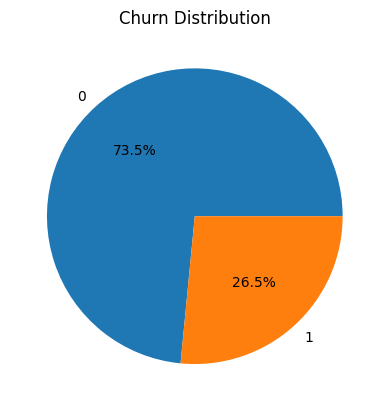

In [123]:
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Churn Distribution")
plt.show()

# We see data is imbalanced

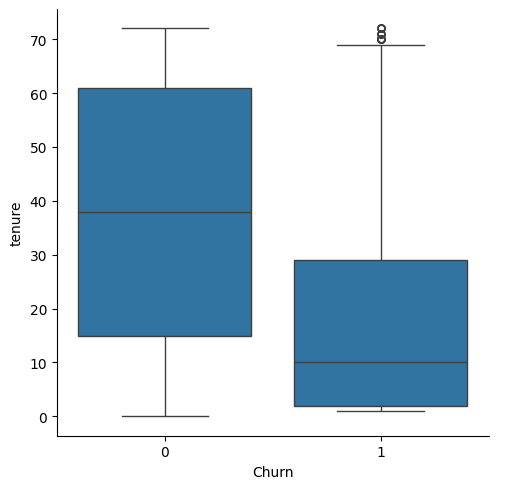

In [124]:
sns.catplot(data=df,x='Churn',y='tenure',kind='box')
plt.show()

# Less tenure People are like to churn more

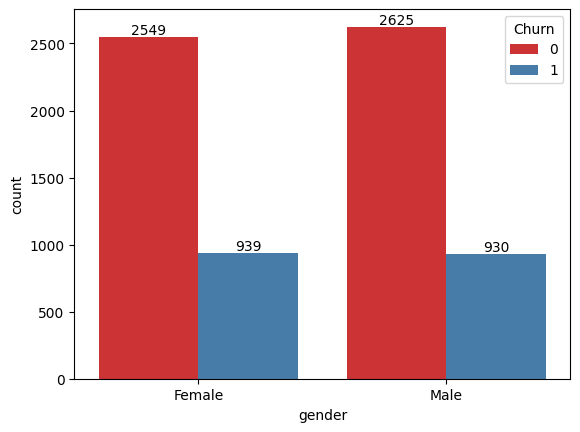

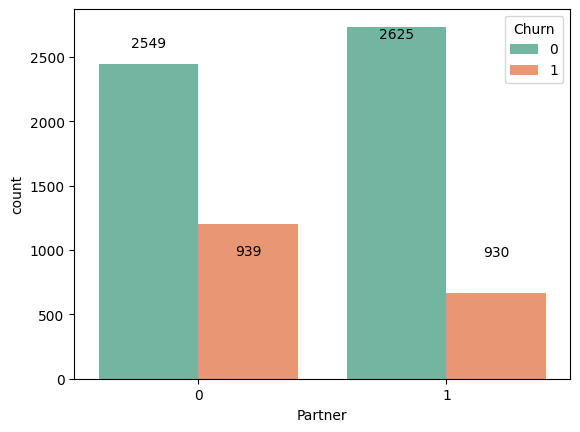

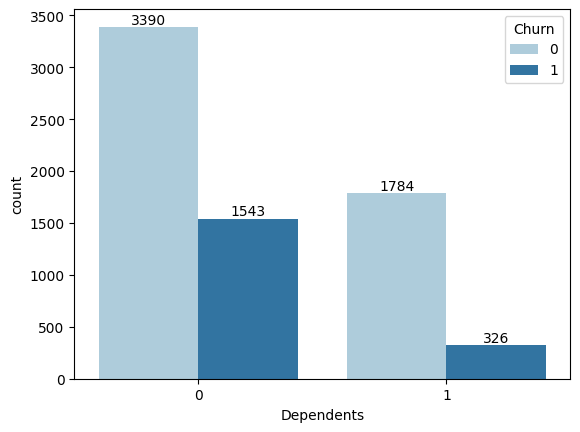

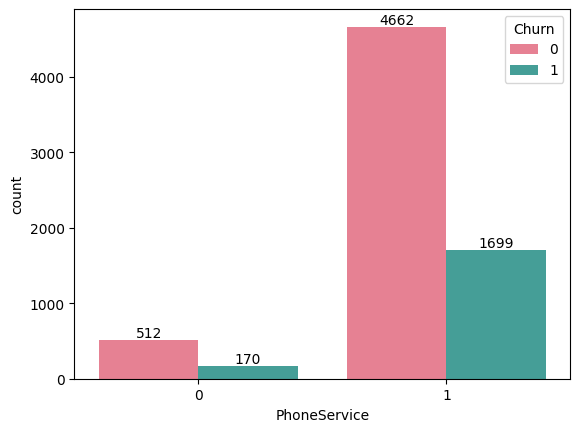

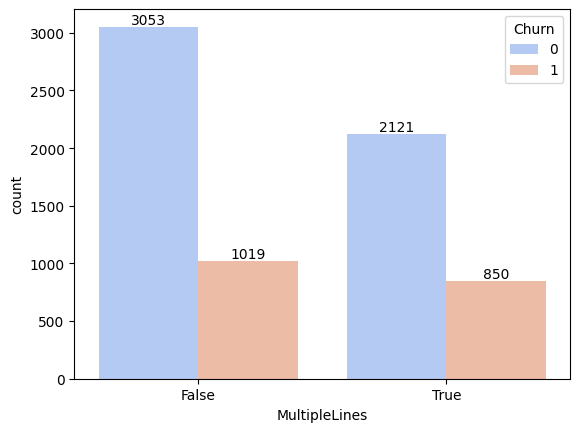

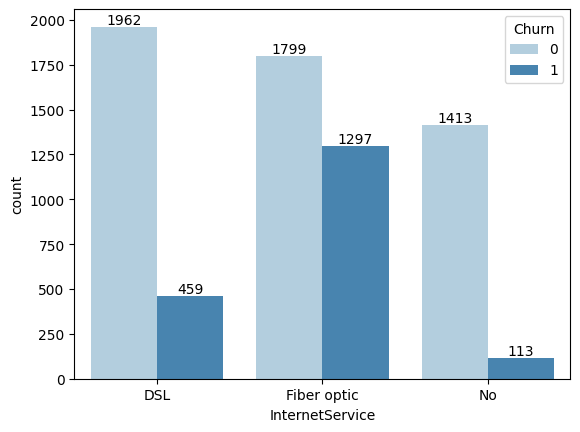

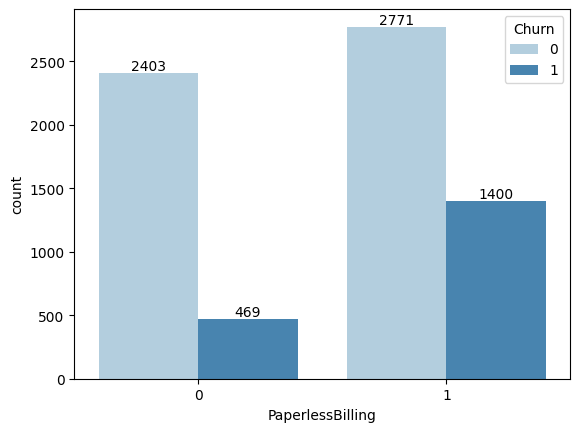

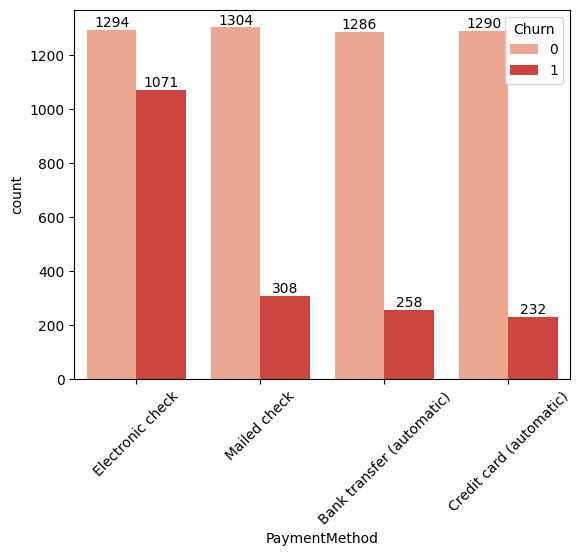

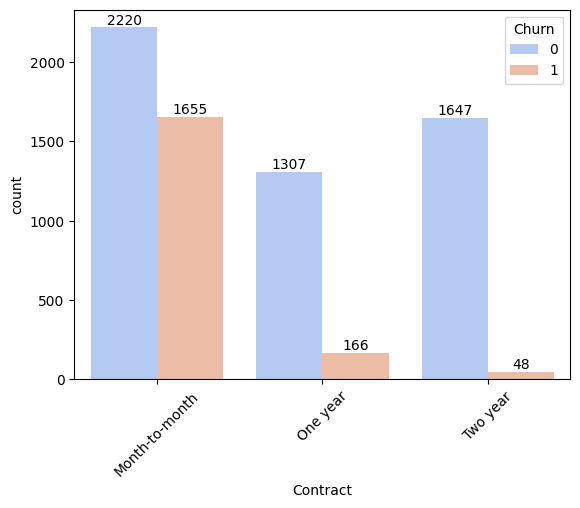

In [125]:
ax1 = sns.countplot(data=df, x="gender", hue="Churn", palette="Set1")
for container in ax1.containers:
    ax1.bar_label(container)
plt.show()

ax2 = sns.countplot(data=df, x="Partner", hue="Churn", palette="Set2")
for container in ax1.containers:
    ax2.bar_label(container)
plt.show()

ax3 = sns.countplot(data=df, x="Dependents", hue="Churn", palette="Paired")
for container in ax3.containers:
    ax3.bar_label(container)
plt.show()

ax4 = sns.countplot(data=df, x="PhoneService", hue="Churn", palette="husl")
for container in ax4.containers:
    ax4.bar_label(container)
plt.show()


ax5 = sns.countplot(data=df, x="MultipleLines", hue="Churn", palette="coolwarm")
for container in ax5.containers:
    ax5.bar_label(container)
plt.show()


ax6 = sns.countplot(data=df, x="InternetService", hue="Churn", palette="Blues")
for container in ax6.containers:
    ax6.bar_label(container)
plt.show()


ax7 = sns.countplot(data=df, x="PaperlessBilling", hue="Churn", palette="Blues")
for container in ax7.containers:
    ax7.bar_label(container)
plt.show()

ax8 = sns.countplot(data=df, x="PaymentMethod", hue="Churn", palette="Reds")
plt.xticks(rotation=45)
for container in ax8.containers:
    ax8.bar_label(container)
plt.show()

ax9 = sns.countplot(data=df, x="Contract", hue="Churn", palette="coolwarm")
plt.xticks(rotation=45)
for container in ax9.containers:
    ax9.bar_label(container)
plt.show()